In [1]:
import pymysql
import pandas as pd
from datetime import datetime, timedelta
from DATA.stock_invest_function import *

class USTradeExportExtractor:
    def __init__(self, host='localhost', user='root', password='your_password',
                 database='your_database', port=3306, charset='utf8mb4'):
        """데이터베이스 연결 초기화"""
        self.connection_params = {
            'host': host,
            'user': user,
            'password': password,
            'database': database,
            'port': port,
            'charset': charset
        }
        print(f"DB 연결 설정: {user}@{host}:{port}/{database}")

    def get_connection(self):
        """데이터베이스 연결 생성"""
        return pymysql.connect(**self.connection_params)

    def extract_by_date_string(self, target_date):
        """
        특정 날짜의 데이터 추출 (YYYY-MM-DD 형식)

        Parameters:
        target_date: str, 예: '2026-01-22'
        """
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) = %s
            ORDER BY hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[target_date])
            return df
        finally:
            conn.close()

    def extract_by_date_range(self, start_date, end_date):
        """
        날짜 범위의 데이터 추출

        Parameters:
        start_date: str, 예: '2026-01-20'
        end_date: str, 예: '2026-01-23'
        """
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) BETWEEN %s AND %s
            ORDER BY created_at, hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[start_date, end_date])
            return df
        finally:
            conn.close()

    def extract_latest_data(self):
        """가장 최근 created_at 날짜의 데이터만 추출"""
        conn = self.get_connection()
        try:
            # 먼저 최신 날짜 찾기
            query_latest = """
            SELECT DATE(MAX(created_at)) as latest_date
            FROM us_trade_export_monthly_with_forecast
            """
            latest_date = pd.read_sql(query_latest, conn).iloc[0, 0]

            # 최신 날짜의 데이터 추출
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) = %s
            ORDER BY hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[latest_date])
            return df, latest_date
        finally:
            conn.close()

    def extract_by_datetime_range(self, start_datetime, end_datetime):
        """
        시간까지 포함한 정밀한 범위 추출

        Parameters:
        start_datetime: str, 예: '2026-01-22 17:00:00'
        end_datetime: str, 예: '2026-01-22 18:00:00'
        """
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE created_at BETWEEN %s AND %s
            ORDER BY created_at, hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[start_datetime, end_datetime])
            return df
        finally:
            conn.close()

    def extract_recent_n_days(self, n_days=7):
        """최근 N일간의 데이터 추출"""
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) >= DATE_SUB(CURDATE(), INTERVAL %s DAY)
            ORDER BY created_at DESC, hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[n_days])
            return df
        finally:
            conn.close()

    def get_distinct_created_dates(self):
        """저장된 모든 고유 날짜 목록 조회"""
        conn = self.get_connection()
        try:
            query = """
            SELECT DISTINCT DATE(created_at) as created_date,
                   COUNT(*) as record_count
            FROM us_trade_export_monthly_with_forecast
            GROUP BY DATE(created_at)
            ORDER BY created_date DESC
            """
            df = pd.read_sql(query, conn)
            return df
        finally:
            conn.close()

    def extract_by_hs_code_and_date(self, hs_code, target_date):
        """특정 HS 코드와 날짜의 데이터 추출"""
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE hs_code = %s AND DATE(created_at) = %s
            ORDER BY date_month_end
            """
            df = pd.read_sql(query, conn, params=[hs_code, target_date])
            return df
        finally:
            conn.close()

    def get_all_hs_codes(self, target_date=None):
        """특정 날짜(또는 최신)의 모든 HS 코드 목록 조회"""
        conn = self.get_connection()
        try:
            if target_date:
                query = """
                SELECT DISTINCT hs_code
                FROM us_trade_export_monthly_with_forecast
                WHERE DATE(created_at) = %s
                ORDER BY hs_code
                """
                df = pd.read_sql(query, conn, params=[target_date])
            else:
                query = """
                SELECT DISTINCT hs_code
                FROM us_trade_export_monthly_with_forecast
                WHERE DATE(created_at) = (
                    SELECT DATE(MAX(created_at))
                    FROM us_trade_export_monthly_with_forecast
                )
                ORDER BY hs_code
                """
                df = pd.read_sql(query, conn)
            return df['hs_code'].tolist()
        finally:
            conn.close()




In [2]:
# 사용 예시

# db_info = {
#     'user': 'stox7412',         # 예: 'root'
#     'password': 'Apt106503!~', # 예: '1234'
#     # 'host' : '192.168.0.230',
#     'host': get_db_host(),         # 예: 'localhost' 또는 IP
#     'port': 3307,              # 기본 포트는 보통 3306
#     'database': 'investar'        # 예: 'trade_data'
# }


extractor = USTradeExportExtractor(
    host=get_db_host(),
    user='stox7412',
    password='Apt106503!~',
    database='investar',
    port=3307
)

# 1. 특정 날짜 데이터 추출
print("=== 특정 날짜 데이터 추출 ===")
df_today = extractor.extract_by_date_string('2026-01-22')
print(f"추출된 레코드 수: {len(df_today)}")
print(df_today.head())

# # 2. 가장 최근 데이터 추출
# print("\n=== 최신 데이터 추출 ===")
# df_latest, latest_date = extractor.extract_latest_data()
# print(f"최신 날짜: {latest_date}")
# print(f"추출된 레코드 수: {len(df_latest)}")
#
# # 3. 날짜 범위로 추출
# print("\n=== 날짜 범위 데이터 추출 ===")
# df_range = extractor.extract_by_date_range('2026-01-20', '2026-01-23')
# print(f"추출된 레코드 수: {len(df_range)}")
#
# # 4. 최근 7일 데이터
# print("\n=== 최근 7일 데이터 ===")
# df_week = extractor.extract_recent_n_days(7)
# print(f"추출된 레코드 수: {len(df_week)}")
#
# # 5. 저장된 날짜 목록 확인
# print("\n=== 저장된 날짜 목록 ===")
# dates_df = extractor.get_distinct_created_dates()
# print(dates_df)
#
# # 6. 특정 HS 코드와 날짜로 추출
# print("\n=== 특정 HS 코드 데이터 ===")
# df_hs = extractor.extract_by_hs_code_and_date('100199', '2026-01-22')
# print(f"추출된 레코드 수: {len(df_hs)}")

# 7. CSV로 저장
# df_latest.to_csv('latest_export_forecast.csv', index=False, encoding='utf-8-sig')
# print("\n최신 데이터를 CSV로 저장했습니다.")

DB 연결 설정: stox7412@192.168.0.230:3307/investar
=== 특정 날짜 데이터 추출 ===
추출된 레코드 수: 78076
  hs_code date_month_end       expDlr  expDlr_forecast  is_forecast  \
0  100199     2013-01-31  738003507.0      738003507.0            0   
1  100199     2013-02-28  844245600.0      844245600.0            0   
2  100199     2013-03-31  936336637.0      936336637.0            0   
3  100199     2013-04-30  952592398.0      952592398.0            0   
4  100199     2013-05-31  804767583.0      804767583.0            0   

                                              params          created_at  
0  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
1  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
2  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
3  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
4  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  


In [3]:
len(df_today['hs_code'].unique())

478

In [6]:
df_today[df_today['hs_code'] == '854231'].tail(24)

,hs_code,date_month_end,expDlr,expDlr_forecast,is_forecast,params,created_at
58619,854231,2025-05-31,2.816068e+09,2.816068e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58620,854231,2025-06-30,2.743521e+09,2.743521e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58621,854231,2025-07-31,2.901765e+09,2.901765e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58622,854231,2025-08-31,2.804615e+09,2.804615e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58623,854231,2025-09-30,2.643287e+09,2.643287e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58624,854231,2025-10-31,2.982020e+09,2.982020e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58625,854231,2025-11-30,NaN,2.839274e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58626,854231,2025-12-31,NaN,2.779283e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58627,854231,2026-01-31,NaN,2.953091e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58628,854231,2026-02-28,NaN,2.564394e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20


#### 2. 향후 12개월 수출 증가율이 높은 아이템 추출

In [22]:
import os
from sqlalchemy import create_engine


def calculate_export_growth_ranking(db_info, past_date, future_date, save_path=None):
    """
    과거 12개월 대비 미래 12개월 수출액 증가율을 계산하고 랭킹 산출

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보
        예: {'host': 'localhost', 'user': 'root', 'password': 'pwd',
             'database': 'db_name', 'port': 3306}
    past_date : str
        과거 기준일 (형식: 'YYYY-MM-DD')
    future_date : str
        미래 기준일 (형식: 'YYYY-MM-DD')
    save_path : str, optional
        CSV 파일 저장 경로 (기본값: None)

    Returns:
    --------
    pd.DataFrame
        HS 코드별 성장률 랭킹 데이터프레임
    """

    # SQLAlchemy 엔진 생성
    engine = create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
        f"{db_info['host']}:{db_info.get('port', 3306)}/{db_info['database']}"
    )

    # 날짜 문자열을 datetime 객체로 변환
    past_dt = pd.to_datetime(past_date)
    future_dt = pd.to_datetime(future_date)

    # 과거 12개월 범위 계산 (past_date 포함, 이전 11개월)
    past_start = past_dt - pd.DateOffset(months=11)
    past_end = past_dt

    # 미래 12개월 범위 계산 (future_date부터 이후 11개월)
    future_start = future_dt
    future_end = future_dt + pd.DateOffset(months=11)

    print("=" * 80)
    print("수출 성장률 분석 시작")
    print("=" * 80)
    print(f"\n📅 분석 기간:")
    print(f"  과거 12개월: {past_start.strftime('%Y-%m-%d')} ~ {past_end.strftime('%Y-%m-%d')}")
    print(f"  미래 12개월: {future_start.strftime('%Y-%m-%d')} ~ {future_end.strftime('%Y-%m-%d')}")

    # 전체 데이터 로드
    query = """
    SELECT
        hs_code,
        date_month_end,
        expDlr,
        expDlr_forecast,
        is_forecast
    FROM us_trade_export_monthly_with_forecast
    ORDER BY hs_code, date_month_end
    """

    print(f"\n📊 데이터 로딩 중...")
    df = pd.read_sql(query, engine)
    df['date_month_end'] = pd.to_datetime(df['date_month_end'])

    print(f"  총 레코드 수: {len(df):,}")
    print(f"  HS 코드 수: {df['hs_code'].nunique():,}")

    # 실제 수출액과 예측 수출액 통합
    df['export_value'] = df.apply(
        lambda x: x['expDlr_forecast'] if x['is_forecast'] == 1 else x['expDlr'],
        axis=1
    )

    # 과거 12개월 데이터 필터링
    past_df = df[
        (df['date_month_end'] >= past_start) &
        (df['date_month_end'] <= past_end)
    ].copy()

    # 미래 12개월 데이터 필터링
    future_df = df[
        (df['date_month_end'] >= future_start) &
        (df['date_month_end'] <= future_end)
    ].copy()

    print(f"\n📈 필터링 결과:")
    print(f"  과거 12개월 레코드: {len(past_df):,}")
    print(f"  미래 12개월 레코드: {len(future_df):,}")

    # HS 코드별 과거 12개월 합계
    past_sum = past_df.groupby('hs_code').agg({
        'export_value': 'sum'
    }).reset_index()
    past_sum.columns = ['hs_code', 'recent_12month']

    # HS 코드별 미래 12개월 합계
    future_sum = future_df.groupby('hs_code').agg({
        'export_value': 'sum'
    }).reset_index()
    future_sum.columns = ['hs_code', 'future_12month']

    # 데이터 병합
    result = pd.merge(past_sum, future_sum, on='hs_code', how='inner')

    # 성장률 계산 (과거가 0인 경우 처리)
    result['growth_rate'] = result.apply(
        lambda x: (
            ((x['future_12month'] - x['recent_12month']) / x['recent_12month'] * 100)
            if x['recent_12month'] > 0
            else (100.0 if x['future_12month'] > 0 else 0.0)
        ),
        axis=1
    )

    # 성장률 기준 내림차순 정렬
    result = result.sort_values('growth_rate', ascending=False).reset_index(drop=True)

    # 날짜 정보 추가
    result.insert(0, 'past_date', past_date)
    result.insert(1, 'future_date', future_date)

    # 랭킹 추가
    result.insert(0, 'rank', range(1, len(result) + 1))

    # 숫자 포맷팅을 위한 출력용 데이터프레임 생성
    display_df = result.copy()
    display_df['recent_12month'] = display_df['recent_12month'].apply(lambda x: f"{x:,.0f}")
    display_df['future_12month'] = display_df['future_12month'].apply(lambda x: f"{x:,.0f}")
    display_df['growth_rate'] = display_df['growth_rate'].apply(lambda x: f"{x:,.2f}%")

    print("\n" + "=" * 80)
    print("분석 완료")
    print("=" * 80)
    print(f"\n총 {len(result):,}개 HS 코드 분석 완료")
    print(f"\n📊 상위 10개 HS 코드 (성장률 기준):")
    print(display_df.head(10).to_string(index=False))

    # 기본 통계
    print(f"\n📈 성장률 통계:")
    print(f"  평균 성장률: {result['growth_rate'].mean():.2f}%")
    print(f"  중앙값: {result['growth_rate'].median():.2f}%")
    print(f"  최대값: {result['growth_rate'].max():.2f}%")
    print(f"  최소값: {result['growth_rate'].min():.2f}%")
    print(f"  표준편차: {result['growth_rate'].std():.2f}%")

    # 성장률 구간별 분포
    positive_growth = (result['growth_rate'] > 0).sum()
    negative_growth = (result['growth_rate'] < 0).sum()
    no_change = (result['growth_rate'] == 0).sum()

    print(f"\n📊 성장률 분포:")
    print(f"  성장 (>0%): {positive_growth:,}개 ({positive_growth/len(result)*100:.1f}%)")
    print(f"  감소 (<0%): {negative_growth:,}개 ({negative_growth/len(result)*100:.1f}%)")
    print(f"  변화없음 (=0%): {no_change:,}개 ({no_change/len(result)*100:.1f}%)")

    # CSV 파일 저장
    if save_path:
        # 디렉토리가 없으면 생성
        os.makedirs(save_path, exist_ok=True)

        # 파일명 생성
        past_str = past_date.replace('-', '')
        future_str = future_date.replace('-', '')
        output_filename = f"export_growth_ranking_{past_str}_to_{future_str}.csv"
        output_filepath = os.path.join(save_path, output_filename)

        # CSV 저장
        result.to_csv(output_filepath, index=False, encoding='utf-8-sig')
        print(f"\n💾 결과가 저장되었습니다:")
        print(f"   {output_filepath}")

    engine.dispose()

    return result


# 사용 예시
# if __name__ == "__main__":
#     # 데이터베이스 연결 정보 설정
#     db_info = {
#         'host': 'localhost',
#         'user': 'your_username',
#         'password': 'your_password',
#         'database': 'your_database',
#         'port': 3306
#     }
#
#     # 과거 기준일과 미래 기준일 설정
#     past_date = '2014-01-31'      # 과거 12개월의 끝 시점
#     future_date = '2015-01-31'    # 미래 12개월의 시작 시점
#
#     # 성장률 랭킹 계산
#     ranking_df = calculate_export_growth_ranking(db_info, past_date, future_date)
#
#     # 결과를 CSV 파일로 저장 (선택사항)
#     output_filename = f"export_growth_ranking_{past_date}_to_{future_date}.csv"
#     ranking_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
#     print(f"\n💾 결과가 '{output_filename}' 파일로 저장되었습니다.")
#
#     # 상위 20개만 별도로 확인
#     print("\n" + "=" * 80)
#     print("TOP 20 성장률 HS 코드")
#     print("=" * 80)
#     print(ranking_df.head(20).to_string(index=False))




In [23]:
# 2. DB 및 객체 초기화
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

# 저장 경로 지정
save_path = r"C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\US_Export_growth"

# 함수 호출
ranking_df = calculate_export_growth_ranking(
    db_info=db_info,
    past_date='2025-10-31',
    future_date='2025-11-30',
    save_path=save_path  # 저장 경로 전달
)

# 결과를 CSV 파일로 저장 (선택사항)
# output_filename = f"export_growth_ranking_{past_date}_to_{future_date}.csv"
# ranking_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
# print(f"\n💾 결과가 '{output_filename}' 파일로 저장되었습니다.")

# 상위 20개만 별도로 확인
print("\n" + "=" * 80)
print("TOP 20 성장률 HS 코드")
print("=" * 80)
print(ranking_df.head(20).to_string(index=False))

수출 성장률 분석 시작

📅 분석 기간:
  과거 12개월: 2024-11-30 ~ 2025-10-31
  미래 12개월: 2025-11-30 ~ 2026-10-30

📊 데이터 로딩 중...
  총 레코드 수: 153,762
  HS 코드 수: 478

📈 필터링 결과:
  과거 12개월 레코드: 11,472
  미래 12개월 레코드: 10,516

분석 완료

총 478개 HS 코드 분석 완료

📊 상위 10개 HS 코드 (성장률 기준):
 rank  past_date future_date hs_code                                                                                                                                                                                                             recent_12month                                                                                                                                                                                                                                                                             future_12month                                                                                                                                                                                                                    

In [24]:
ranking_df[ranking_df['hs_code'] == '854232']

,rank,past_date,future_date,hs_code,recent_12month,future_12month,growth_rate
285,286,2025-10-31,2025-11-30,854232,4.848316e+09,4.378965e+09,-9.680696


In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [32]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

def visualize_export_forecast(db_info, hs_code, past_date='2014-01-31',
                              future_months=12, figsize=(14, 7)):
    """
    HS 코드별 수출 실적 및 예측 시각화

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보
    hs_code : str
        조회할 HS 코드
    past_date : str
        실적과 예측의 구분 기준일 (형식: 'YYYY-MM-DD')
    future_months : int
        향후 예측 개월 수 (기본값: 12)
    figsize : tuple
        그래프 크기 (기본값: (14, 7))

    Returns:
    --------
    tuple
        (fig, ax, growth_rate) - 그래프 객체와 성장률
    """

    # SQLAlchemy 엔진 생성
    engine = create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
        f"{db_info['host']}:{db_info.get('port', 3306)}/{db_info['database']}"
    )

    # 데이터 조회
    query = f"""
    SELECT
        hs_code,
        date_month_end,
        expDlr,
        expDlr_forecast,
        is_forecast
    FROM us_trade_export_monthly_with_forecast
    WHERE hs_code = '{hs_code}'
    ORDER BY date_month_end
    """

    print(f"📊 HS Code {hs_code} 데이터 조회 중...")
    df = pd.read_sql(query, engine)
    engine.dispose()

    if df.empty:
        print(f"❌ HS Code {hs_code}에 대한 데이터가 없습니다.")
        return None, None, None

    # 날짜 변환
    df['date_month_end'] = pd.to_datetime(df['date_month_end'])
    past_dt = pd.to_datetime(past_date)

    # 수출액 통합 (실적 우선, 없으면 예측값)
    df['export_value'] = df.apply(
        lambda x: x['expDlr'] if pd.notna(x['expDlr']) and x['expDlr'] > 0
        else x['expDlr_forecast'],
        axis=1
    )

    # 실적과 예측 데이터 분리
    actual_df = df[df['date_month_end'] <= past_dt].copy()
    forecast_df = df[df['date_month_end'] > past_dt].copy()

    print(f"✓ 실적 데이터: {len(actual_df)}개")
    print(f"✓ 예측 데이터: {len(forecast_df)}개")

    # 향후 12개월 예측 성장률 계산
    if len(forecast_df) >= future_months:
        # 과거 12개월 (past_date 기준 이전 12개월)
        past_12m_start = past_dt - pd.DateOffset(months=11)
        past_12m_df = df[
            (df['date_month_end'] >= past_12m_start) &
            (df['date_month_end'] <= past_dt)
        ]
        past_12m_sum = past_12m_df['export_value'].sum()

        # 향후 12개월
        future_12m_df = forecast_df.head(future_months)
        future_12m_sum = future_12m_df['export_value'].sum()

        # 성장률 계산
        if past_12m_sum > 0:
            growth_rate = ((future_12m_sum - past_12m_sum) / past_12m_sum) * 100
        else:
            growth_rate = 0.0

        print(f"\n📈 성장률 분석:")
        print(f"  과거 12개월 합계: ${past_12m_sum:,.0f}")
        print(f"  향후 12개월 예측: ${future_12m_sum:,.0f}")
        print(f"  성장률: {growth_rate:+.2f}%")
    else:
        growth_rate = None
        print(f"\n⚠️ 향후 {future_months}개월 예측 데이터가 부족합니다.")

    # 그래프 생성
    fig, ax = plt.subplots(figsize=figsize)

    # 실적 데이터 플롯 (실선)
    if not actual_df.empty:
        ax.plot(actual_df['date_month_end'],
                actual_df['export_value'],
                color='#2E86AB',
                linewidth=2.5,
                marker='o',
                markersize=4,
                label='실적 (Actual)',
                zorder=3)

    # 예측 데이터 플롯 (점선)
    if not forecast_df.empty:
        # 연결을 위해 마지막 실적 데이터 포인트 추가
        if not actual_df.empty:
            last_actual = actual_df.iloc[-1]
            forecast_plot_df = pd.concat([
                pd.DataFrame([{
                    'date_month_end': last_actual['date_month_end'],
                    'export_value': last_actual['export_value']
                }]),
                forecast_df
            ], ignore_index=True)
        else:
            forecast_plot_df = forecast_df

        # 성장률에 따른 레이블 생성
        if growth_rate is not None:
            forecast_label = f'예측 (Forecast) - 향후 12개월 성장률: {growth_rate:+.2f}%'
        else:
            forecast_label = '예측 (Forecast)'

        ax.plot(forecast_plot_df['date_month_end'],
                forecast_plot_df['export_value'],
                color='#A23B72',
                linewidth=2.5,
                linestyle='--',
                marker='s',
                markersize=4,
                label=forecast_label,
                zorder=3)

    # 실적과 예측 구분선
    ax.axvline(x=past_dt, color='gray', linestyle=':', linewidth=1.5,
               alpha=0.7, label=f'기준일: {past_date}')

    # 그래프 스타일링
    ax.set_xlabel('날짜', fontsize=12, fontweight='bold')
    ax.set_ylabel('수출액 (USD)', fontsize=12, fontweight='bold')
    ax.set_title(f'HS Code {hs_code} - 수출 실적 및 예측',
                fontsize=16, fontweight='bold', pad=20)

    # Y축 포맷 (천 단위 구분)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

    # X축 날짜 포맷
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    # 그리드
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    # 범례
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

    # 레이아웃 조정
    plt.tight_layout()

    print(f"\n✓ 시각화 완료")

    return fig, ax, growth_rate


def visualize_multiple_hs_codes(db_info, hs_codes, past_date='2014-01-31',
                                future_months=12, figsize=(14, 8)):
    """
    여러 HS 코드를 한 그래프에 표시

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보
    hs_codes : list
        조회할 HS 코드 리스트
    past_date : str
        실적과 예측의 구분 기준일
    future_months : int
        향후 예측 개월 수
    figsize : tuple
        그래프 크기

    Returns:
    --------
    tuple
        (fig, ax, growth_rates_dict) - 그래프 객체와 성장률 딕셔너리
    """

    # SQLAlchemy 엔진 생성
    engine = create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
        f"{db_info['host']}:{db_info.get('port', 3306)}/{db_info['database']}"
    )

    # 색상 팔레트
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E',
              '#BC4B51', '#5B8E7D', '#8B5A3C', '#4A5859', '#C9ADA7']

    fig, ax = plt.subplots(figsize=figsize)
    past_dt = pd.to_datetime(past_date)
    growth_rates = {}

    for idx, hs_code in enumerate(hs_codes):
        color = colors[idx % len(colors)]

        # 데이터 조회
        query = f"""
        SELECT
            hs_code,
            date_month_end,
            expDlr,
            expDlr_forecast,
            is_forecast
        FROM investarus_trade_export_monthly_with_forecast
        WHERE hs_code = '{hs_code}'
        ORDER BY date_month_end
        """

        df = pd.read_sql(query, engine)

        if df.empty:
            print(f"⚠️ HS Code {hs_code}: 데이터 없음")
            continue

        df['date_month_end'] = pd.to_datetime(df['date_month_end'])
        df['export_value'] = df.apply(
            lambda x: x['expDlr'] if pd.notna(x['expDlr']) and x['expDlr'] > 0
            else x['expDlr_forecast'],
            axis=1
        )

        # 실적과 예측 분리
        actual_df = df[df['date_month_end'] <= past_dt].copy()
        forecast_df = df[df['date_month_end'] > past_dt].copy()

        # 성장률 계산
        if len(forecast_df) >= future_months:
            past_12m_start = past_dt - pd.DateOffset(months=11)
            past_12m_df = df[
                (df['date_month_end'] >= past_12m_start) &
                (df['date_month_end'] <= past_dt)
            ]
            past_12m_sum = past_12m_df['export_value'].sum()
            future_12m_sum = forecast_df.head(future_months)['export_value'].sum()

            if past_12m_sum > 0:
                growth_rate = ((future_12m_sum - past_12m_sum) / past_12m_sum) * 100
            else:
                growth_rate = 0.0

            growth_rates[hs_code] = growth_rate
        else:
            growth_rates[hs_code] = None

        # 실적 플롯
        if not actual_df.empty:
            ax.plot(actual_df['date_month_end'],
                   actual_df['export_value'],
                   color=color,
                   linewidth=2,
                   marker='o',
                   markersize=3,
                   label=f'{hs_code} (실적)')

        # 예측 플롯
        if not forecast_df.empty:
            if not actual_df.empty:
                last_actual = actual_df.iloc[-1]
                forecast_plot_df = pd.concat([
                    pd.DataFrame([{
                        'date_month_end': last_actual['date_month_end'],
                        'export_value': last_actual['export_value']
                    }]),
                    forecast_df
                ], ignore_index=True)
            else:
                forecast_plot_df = forecast_df

            growth_label = f' ({growth_rates[hs_code]:+.1f}%)' if growth_rates[hs_code] is not None else ''

            ax.plot(forecast_plot_df['date_month_end'],
                   forecast_plot_df['export_value'],
                   color=color,
                   linewidth=2,
                   linestyle='--',
                   marker='s',
                   markersize=3,
                   label=f'{hs_code} (예측{growth_label})')

    engine.dispose()

    # 구분선
    ax.axvline(x=past_dt, color='gray', linestyle=':', linewidth=1.5,
               alpha=0.7, label=f'기준일: {past_date}')

    # 그래프 스타일링
    ax.set_xlabel('날짜', fontsize=12, fontweight='bold')
    ax.set_ylabel('수출액 (USD)', fontsize=12, fontweight='bold')
    ax.set_title('HS Code별 수출 실적 및 예측 비교',
                fontsize=16, fontweight='bold', pad=20)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, ncol=2)

    plt.tight_layout()

    return fig, ax, growth_rates


# 사용 예시
# if __name__ == "__main__":
#     # 데이터베이스 연결 정보
#     db_info = {
#         'host': 'localhost',
#         'user': 'your_username',
#         'password': 'your_password',
#         'database': 'your_database',
#         'port': 3306
#     }
#
#     # 단일 HS 코드 시각화
#     print("=" * 80)
#     print("단일 HS Code 시각화")
#     print("=" * 80)
#
#     hs_code = '100199'
#     fig1, ax1, growth_rate = visualize_export_forecast(
#         db_info=db_info,
#         hs_code=hs_code,
#         past_date='2014-01-31',
#         future_months=12,
#         figsize=(14, 7)
#     )
#
#     if fig1:
#         plt.show()
#         # 또는 저장
#         # fig1.savefig(f'export_forecast_{hs_code}.png', dpi=300, bbox_inches='tight')
#
#     # 여러 HS 코드 비교 시각화
#     print("\n" + "=" * 80)
#     print("여러 HS Code 비교 시각화")
#     print("=" * 80)
#
#     hs_codes = ['100199', '100190', '100630']
#     fig2, ax2, growth_rates = visualize_multiple_hs_codes(
#         db_info=db_info,
#         hs_codes=hs_codes,
#         past_date='2014-01-31',
#         future_months=12,
#         figsize=(14, 8)
#     )
#
#     print("\n📊 성장률 요약:")
#     for hs, rate in growth_rates.items():
#         if rate is not None:
#             print(f"  HS {hs}: {rate:+.2f}%")
#         else:
#             print(f"  HS {hs}: 데이터 부족")
#
#     plt.show()

📊 HS Code 260300 데이터 조회 중...
✓ 실적 데이터: 308개
✓ 예측 데이터: 31개

📈 성장률 분석:
  과거 12개월 합계: $6,743,047,357
  향후 12개월 예측: $3,924,396,492
  성장률: -41.80%

✓ 시각화 완료


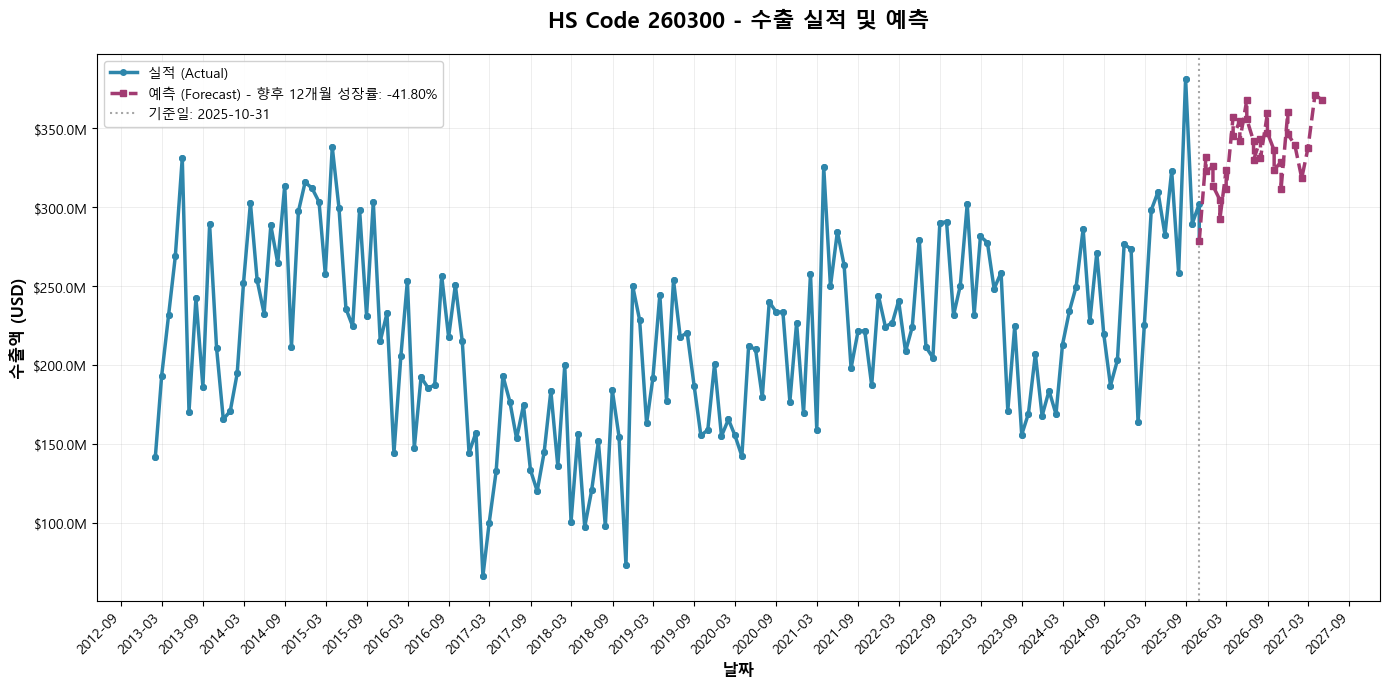

In [44]:
# 단일 HS 코드
fig, ax, growth_rate = visualize_export_forecast(
    db_info=db_info,
    hs_code='260300',
    past_date='2025-10-31',
    future_months=12
)
plt.show()

# # 여러 HS 코드 비교
# hs_codes = ['100199', '100190', '100630']
# fig, ax, growth_rates = visualize_multiple_hs_codes(
#     db_info=db_info,
#     hs_codes=hs_codes,
#     past_date='2014-01-31'
# )
# plt.show()